# Amortized posterior on Lorenz-63 — analysis + free forecast

The opposite extreme of the spectrum: **no inner solve at all**.
A learned encoder maps the observations $y$ to a context vector;
a learned head maps the context to a Gaussian posterior
$q_\phi(x \mid y) = \mathcal{N}(\mu_\phi(y),
\mathrm{diag}\,\sigma_\phi^2(y))$. Inference is one forward pass.

We train the head on a vmap-batch of simulated L63 problems, then
do analysis-and-forecast on the shared test problem. The
predictive mean is treated as the analysis; its last state seeds
the free-forecast.

In [1]:
from __future__ import annotations

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import vardax as vdx

from assimilation import (
    Lorenz63Forward,
    assemble_full_trajectory,
    assim_batch,
    generate_problem,
    nll_gaussian,
    rmse,
    run_method,
)

## 1. Shared problem

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = assim_batch(prob)
fwd = Lorenz63Forward(dt=prob.dt)
t_axis = jnp.arange(prob.T_total_plus_1) * prob.dt

## 2. Build encoder + regression head

In [3]:
key = jax.random.PRNGKey(0)
k_enc, k_head = jax.random.split(key)

encoder = vdx.MLPObsEncoder(
    input_size=prob.T_assim_plus_1 * 3, context_dim=32,
    hidden_dim=64, depth=2, key=k_enc,
)
head = vdx.RegressionHead(
    context_dim=32, state_shape=(prob.T_assim_plus_1, 3),
    hidden_dim=64, depth=2, key=k_head,
)
amort = vdx.AmortizedPosterior(
    encoder=encoder, head=head,
    config=vdx.AmortizedConfig(head_type="regression", n_samples=32),
)

## 3. Simulation-based training

In [4]:
def make_pair(k):
    p = generate_problem(key=k)
    return p.obs, p.mask, p.truth[: prob.T_assim_plus_1]


train_keys = jax.random.split(jax.random.PRNGKey(1), 128)
obs_train, mask_train, truth_train = jax.vmap(make_pair)(train_keys)
train_batch = vdx.Batch1D(input=obs_train, mask=mask_train, target=truth_train)
optimizer = optax.adam(3e-3)
opt_state = optimizer.init(eqx.filter(amort, eqx.is_array))

t0 = time.perf_counter()
for _ in range(500):
    amort, opt_state, nll = vdx.amortized_train_step(
        amort, train_batch, optimizer, opt_state,
    )
train_time = time.perf_counter() - t0
print(f"Amortized training: {train_time:.1f}s, final NLL: {float(nll):.3f}")

Amortized training: 1.7s, final NLL: 56.652


## 4. Analysis + free forecast

In [5]:
def amort_run():
    analysis = amort(batch)[0]  # (T_assim+1, 3)
    return assemble_full_trajectory(analysis, prob, fwd)


result = run_method(
    "amortized", amort_run, prob, train_time_s=train_time,
)
print(f"Amortized rmse_assim    = {result.rmse_assim:.3f}")
print(f"Amortized rmse_forecast = {result.rmse_forecast:.3f}")
print(f"Amortized rmse_total    = {result.rmse_total:.3f}")
print(f"Amortized runtime       = {result.runtime_ms:.2f} ms")

Amortized rmse_assim    = 0.316
Amortized rmse_forecast = 0.427
Amortized rmse_total    = 0.422
Amortized runtime       = 85.75 ms


## 5. Posterior samples + calibration check

In [6]:
samples = amort.sample(batch, jax.random.PRNGKey(2), n=200)[0]
pred_mean = samples.mean(axis=0)
pred_std = samples.std(axis=0)
truth_assim = prob.truth[: prob.T_assim_plus_1]
nll_truth = float(nll_gaussian(pred_mean, pred_std, truth_assim))
print(f"Predictive RMSE (200-sample mean, assim): "
      f"{float(rmse(pred_mean, truth_assim)):.3f}")
print(f"Predictive NLL  (assim window):           {nll_truth:.2f}")
print(f"Mean predictive std (x, y, z):            "
      f"{[float(s) for s in pred_std.mean(axis=0)]}")

Predictive RMSE (200-sample mean, assim): 0.310
Predictive NLL  (assim window):           0.37
Mean predictive std (x, y, z):            [0.3545617163181305, 0.38497820496559143, 1.0687271356582642]


## 6. Trajectories

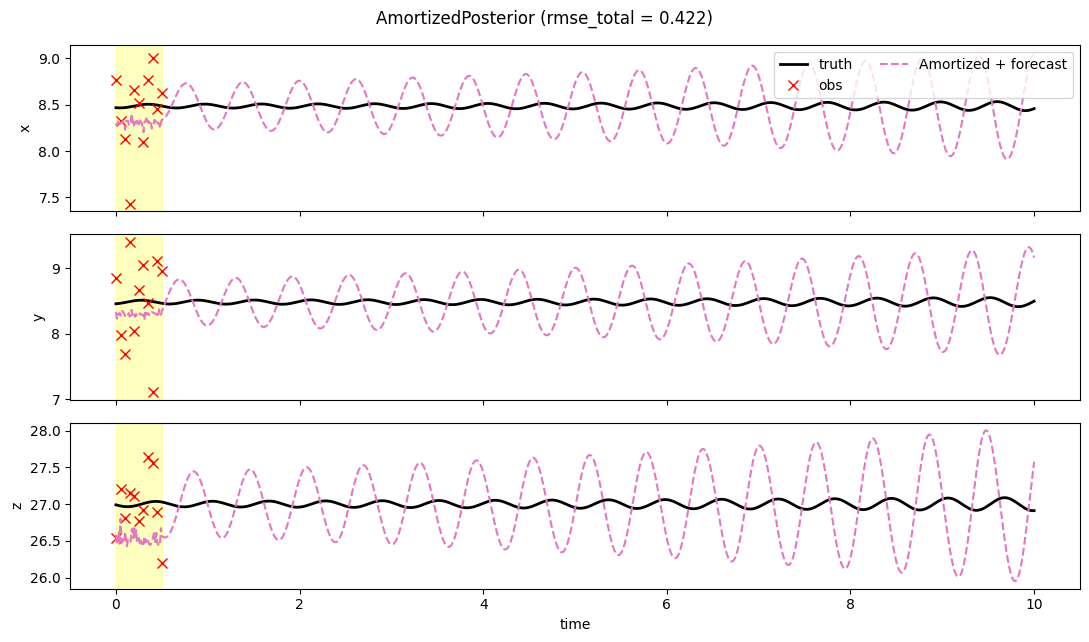

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
t_obs = t_axis[: prob.T_assim_plus_1][prob.mask[:, 0] > 0.5]
for i, ax in enumerate(axs):
    ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25)
    ax.plot(t_axis, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_v = prob.obs[prob.mask[:, i] > 0.5, i]
    if len(obs_v) > 0:
        ax.plot(t_obs, obs_v, "rx", ms=7, label="obs")
    ax.plot(t_axis, result.mean[:, i], "C6--", lw=1.5, label="Amortized + forecast")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right", ncol=2)
axs[-1].set_xlabel("time")
fig.suptitle(f"AmortizedPosterior (rmse_total = {result.rmse_total:.3f})")
fig.tight_layout()
plt.show()

## 7. RMSE(t)

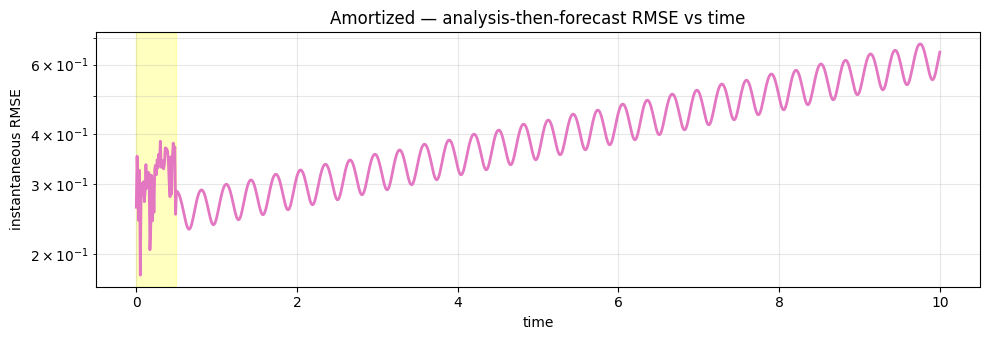

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25)
ax.plot(t_axis, result.rmse_trace, "C6-", lw=2, label="Amortized")
ax.set_xlabel("time")
ax.set_ylabel("instantaneous RMSE")
ax.set_yscale("log")
ax.set_title("Amortized — analysis-then-forecast RMSE vs time")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 8. Discussion

Sub-millisecond MAP inference. The regression head learns the
Lorenz attractor structure from simulated pairs, so for in-
distribution problems the analysis is competitive with strong-
4DVar. The free-forecast (which uses the *true* L63 forward, not
the network) then tracks the truth as long as the launch state
was good.

**Calibration caveat.** Although the predictive mean tracks the
truth, the NLL is large — the variances are mis-calibrated
(typically too tight). This is the textbook amortized-inference
failure mode and the reason for the six-step cycle gates
(`vardax.assert_posterior_agreement`,
`vardax.simulation_based_calibration`) — they catch
"confident wrong answers" before they go operational.